# **Step 1: Install Necessary Libraries**

In [1]:
pip install numpy pandas matplotlib seaborn torch torchvision scikit-learn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 118.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 95.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

# **Step 2: Import Necessary Libraries**

In [2]:
# General utilities
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Image processing
from PIL import Image

# Machine learning utilities
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

# PyTorch libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

# **Step 3: Setting Up the Dataset Structure**

In [4]:
# Mount the Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Define dataset paths
base_directory = "/content/drive/MyDrive/M.Tech Projects/Brain Tumor Detection from MRI Images Using Deep Learning/Dataset/Brain Tumor MRI Dataset"
train_dir = os.path.join(base_directory, "Training")
test_dir = os.path.join(base_directory, "Testing")

# Label mapping for tumor classes
label_map = {
    "notumor": 0,
    "glioma": 1,
    "meningioma": 2,
    "pituitary": 3
}

# Check available categories in training data
categories = os.listdir(train_dir)
print("Tumor Categories:", categories)

# Set device for training (GPU if available)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Tumor Categories: ['notumor', 'meningioma', 'pituitary', 'glioma']
Using device: cuda


# **Step 4: Exploring and Visualizing the Dataset**

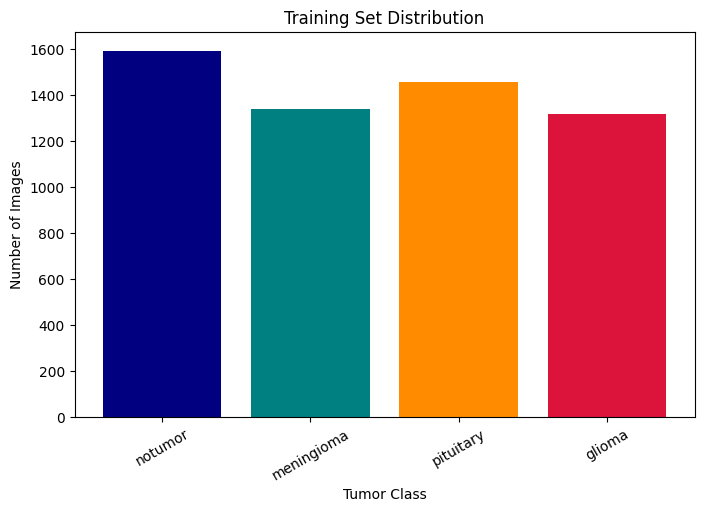

In [7]:
def plot_class_distribution(dataset_type, directory):
    """
    This function plots the distribution of tumor types in the dataset.
    """
    path = os.path.join(directory, dataset_type)
    counts = [len(os.listdir(os.path.join(path, cat))) for cat in categories]

    plt.figure(figsize=(8,5))
    plt.bar(categories, counts, color=['navy', 'teal', 'darkorange', 'crimson'])
    plt.xlabel("Tumor Class")
    plt.ylabel("Number of Images")
    plt.title(f"{dataset_type.capitalize()} Set Distribution")
    plt.xticks(rotation=30)
    plt.show()

# Plot distribution for Training and Testing sets
plot_class_distribution("Training", base_directory)

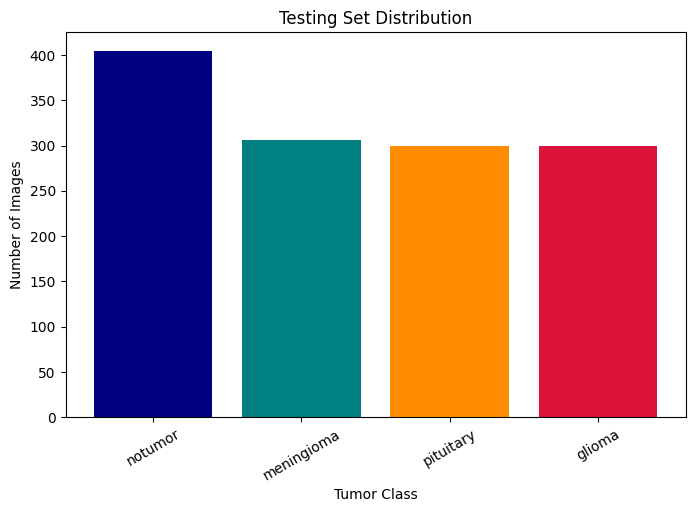

In [8]:
plot_class_distribution("Testing", base_directory)

# **Step 5: Displaying Sample MRI Images**

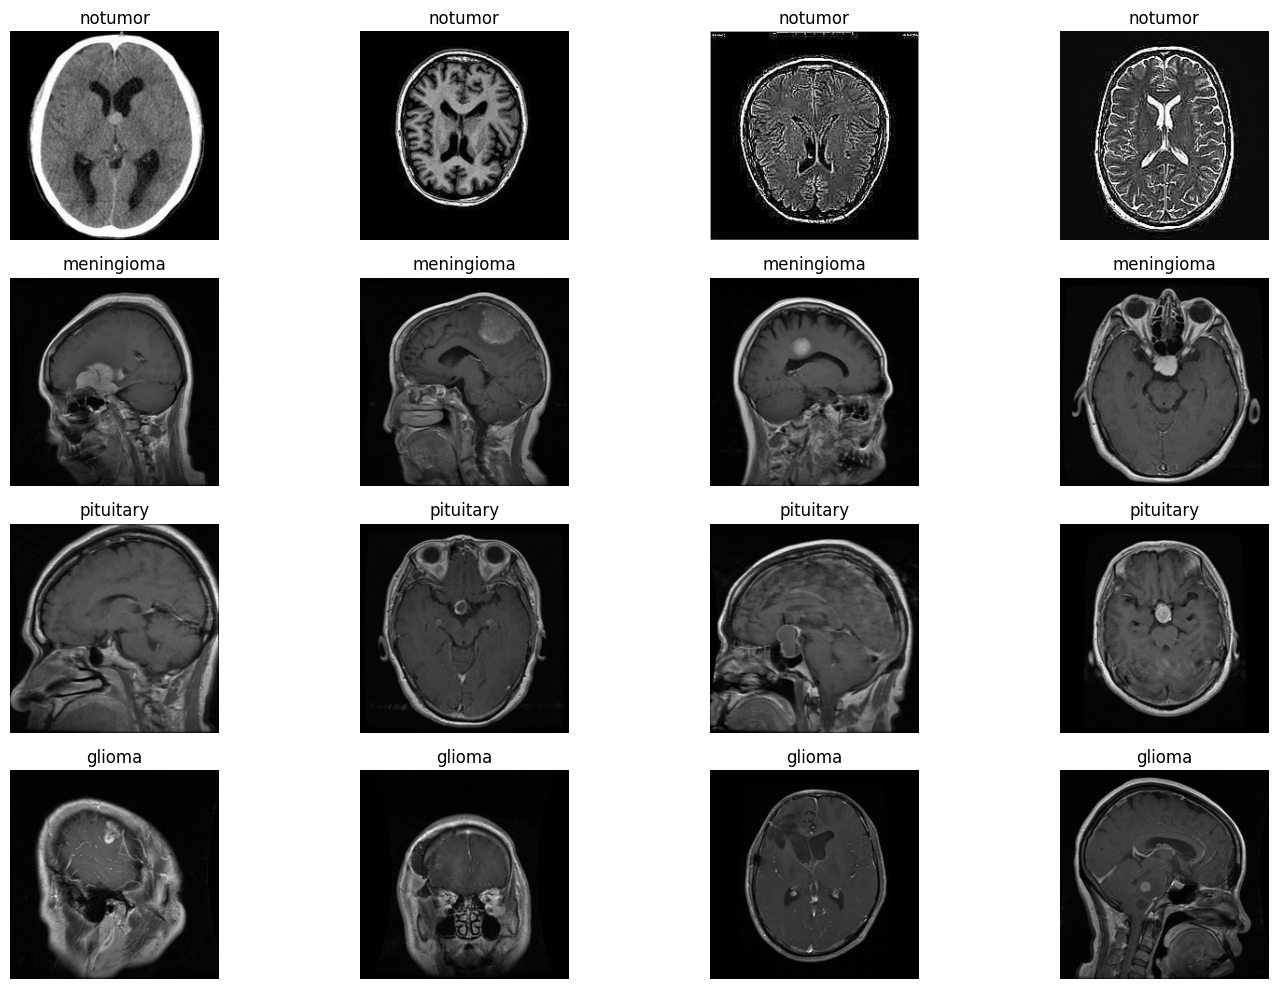

In [9]:
def display_images(dataset_type, num_images=4, image_size=(224, 224)):
    """
    Displays sample MRI images from each tumor category.
    """
    dataset_path = os.path.join(base_directory, dataset_type)
    fig, axes = plt.subplots(len(categories), num_images, figsize=(15, 10))

    for row, category in enumerate(categories):
        category_path = os.path.join(dataset_path, category)
        image_filenames = random.sample(os.listdir(category_path), num_images)  # Select random images

        for col, image_filename in enumerate(image_filenames):
            image_path = os.path.join(category_path, image_filename)
            image = Image.open(image_path).resize(image_size)
            axes[row, col].imshow(image, cmap='gray')
            axes[row, col].axis('off')
            axes[row, col].set_title(f"{category}")

    plt.tight_layout()
    plt.show()

# Show MRI images from training dataset
display_images("Training")

# **Step 6: Preprocessing the Images**

In [10]:
# Define preprocessing transformations
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # Small positional shifts
    transforms.ColorJitter(brightness=(0.8, 1.2)),  # Adjust brightness slightly
    transforms.RandomRotation(10),
    transforms.ToTensor(),  # Convert image to tensor format
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Standard normalization
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),  # Convert image to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Standard normalization
])

# **Step 7: Structuring the Dataset for PyTorch**

In [11]:
class ImageDataset(Dataset):
    """
    Custom PyTorch Dataset class to load MRI images and apply transformations.
    """
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx, 0]
        label = self.dataframe.iloc[idx, 1]
        img = Image.open(img_path).convert('RGB')  # Ensure image is in RGB format

        if self.transform:
            img = self.transform(img)

        return img, label

# **Step 8: Splitting the Dataset and Creating DataLoaders**

In [12]:
# Function to create a dataset DataFrame
def create_dataset(path):
    dataset_list = []
    for category in categories:
        category_path = os.path.join(path, category)
        for file_name in os.listdir(category_path):
            file_path = os.path.join(category_path, file_name)
            # Ensure we're only adding image files
            if os.path.isfile(file_path) and file_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                dataset_list.append([file_path, category])
    return pd.DataFrame(dataset_list, columns=["file_path", "label"])

# Create DataFrame for Training and Testing sets
train_df = create_dataset(train_dir)
test_df = create_dataset(test_dir)

# Convert labels to numerical values
train_df["label"] = train_df["label"].map(label_map)
test_df["label"] = test_df["label"].map(label_map)

# Split test set further into validation and final test set
test_df_split, val_df_split = train_test_split(test_df, test_size=0.5, random_state=42)
test_df_split = test_df_split.reset_index(drop=True)  # Reset indices
val_df_split = val_df_split.reset_index(drop=True)

# Create dataset objects
train_dataset = ImageDataset(train_df, transform=train_transform)
val_dataset = ImageDataset(val_df_split, transform=test_transform)
test_dataset = ImageDataset(test_df_split, transform=test_transform)

# Create DataLoaders for batch processing
batch_size = 32  # Define batch size

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Print dataset sizes
print(f"Training Set: {len(train_dataset)} images")
print(f"Validation Set: {len(val_dataset)} images")
print(f"Test Set: {len(test_dataset)} images")

Training Set: 5712 images
Validation Set: 656 images
Test Set: 655 images


# **Step 9: Building the CNN Model**

In [13]:
class BrainTumorCNN(nn.Module):
    """
    Custom Convolutional Neural Network (CNN) for brain tumor classification.
    """
    def __init__(self, num_classes=4):
        super(BrainTumorCNN, self).__init__()

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.5)

        # Convolutional Layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)   # (B, 32, 224, 224)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # (B, 64, 112, 112)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1) # (B, 128, 56, 56)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1) # (B, 256, 28, 28)
        self.conv5 = nn.Conv2d(256, 256, kernel_size=3, padding=1) # (B, 256, 14, 14)

        # Fully Connected Layers
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(256 * 7 * 7, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = self.pool(self.relu(self.conv4(x)))
        x = self.pool(self.relu(self.conv5(x)))

        x = self.flatten(x)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)

        return x

# Instantiate the model
model = BrainTumorCNN(num_classes=4).to(device)

# **Step 10: Setting Up the Training Process**

In [14]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0007)

# Training function
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10, patience=7):
    """
    Function to train the CNN model with early stopping based on validation loss.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    best_val_loss = float("inf")
    tolerance = 0  # Counter for early stopping
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct_train / total_train

        # Validation phase
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        val_loss = val_loss / len(val_loader)
        val_acc = 100 * correct_val / total_val

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch [{epoch+1}/{num_epochs}]")
        print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_acc:.2f}%")
        print("#" * 80)

        # Early stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "best_brain_tumor_model.pth")
            tolerance = 0
        else:
            tolerance += 1
            if tolerance >= patience:
                print(f"Early stopping triggered after {epoch+1} epochs.")
                break

    return history

# **Step 11: Training the Model**

In [ ]:
# Start training with fewer epochs
print("Starting training with optimized settings...")
history = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=15)

Starting training with optimized settings...
